# NB_FLUX A100 tuning-chain analysis

Direct analysis of the completed A100 raw bundle.

In [1]:
from pathlib import Path
ZIP_PATH = Path(r"C:\Users\Alex\Downloads\NB_FLUX_A100_spin_tuning_results.zip")
if not ZIP_PATH.exists():
    try:
        from google.colab import files
        uploaded = files.upload()
        ZIP_PATH = Path(next(iter(uploaded)))
    except ImportError as exc:
        raise FileNotFoundError("Set ZIP_PATH to NB_FLUX_A100_spin_tuning_results.zip") from exc
print("Using", ZIP_PATH)


Using C:\Users\Alex\Downloads\NB_FLUX_A100_spin_tuning_results.zip


In [2]:
import hashlib, io, json, math, zipfile
import numpy as np

with zipfile.ZipFile(ZIP_PATH) as archive:
    summary_name = next(n for n in archive.namelist() if n.endswith(".summary.json"))
    summary = json.loads(archive.read(summary_name))
    chunks = []
    for record in summary["chunk_records"]:
        payload = archive.read(record["path"])
        assert hashlib.sha256(payload).hexdigest().upper() == record["sha256"]
        with np.load(io.BytesIO(payload), allow_pickle=False) as part:
            chunks.append({key: part[key] for key in part.files})
streams = {
    key: np.concatenate([part[key] for part in chunks], axis=0)
    for key in chunks[0]
}
labels = summary["operator_labels"]

def correlator(values):
    values = np.asarray(values)
    centered = values - values.mean(axis=(0, 3), keepdims=True)
    ncfg, nops, ncomp, nt = centered.shape
    dtype = np.complex128 if np.iscomplexobj(centered) else np.float64
    result = np.empty((nt, nops, nops), dtype=dtype)
    for dt in range(nt):
        shifted = np.roll(centered, -dt, axis=3)
        result[dt] = np.einsum("noct,npct->op", shifted, centered.conj()) / (ncfg*ncomp*nt)
    return 0.5*(result + result.swapaxes(1, 2).conj())

def leading_vector(C, cut=1e-7):
    evals, evecs = np.linalg.eigh(0.5*(C[0] + C[0].T.conj()))
    keep = evals > max(evals.max()*cut, 0)
    W = evecs[:, keep] / np.sqrt(evals[keep])[None, :]
    lam, vec = np.linalg.eigh(W.T.conj() @ (0.5*(C[1]+C[1].T.conj())) @ W)
    return W @ vec[:, np.argmax(lam)]

def curve(values, vector):
    C = correlator(values)
    out = np.real_if_close(np.einsum("i,tij,j->t", vector.conj(), C, vector))
    return np.asarray(out, float) / float(np.real(out[0]))

def moving_blocks(n, block, rng):
    pieces = [(int(rng.integers(n)) + np.arange(block)) % n for _ in range(math.ceil(n/block))]
    return np.concatenate(pieces)[:n]

specs = {
    "raw_P": ("T1", "raw_P_"), "improved_P": ("T1", "improved_P_"),
    "V_T1": ("T1", "V_T1_"), "H_T1": ("T1", "H_T1_"),
    "H_A2": ("A2", "H_A2_"), "H_T2": ("T2", "H_T2_"),
    "torelon": ("torelon", "torelon_"),
}
rng = np.random.default_rng(20260822)
draws = [moving_blocks(48, 8, rng) for _ in range(240)]
exploratory = {}
for name, (channel, prefix) in specs.items():
    indices = [i for i, label in enumerate(labels[channel]) if label.startswith(prefix)]
    values = streams[f"channel_{channel}"][:, indices]
    vector = leading_vector(correlator(values))
    central = curve(values, vector)
    replicas = np.asarray([curve(values[pick], vector) for pick in draws])
    exploratory[name] = {
        "curve": central,
        "error": replicas.std(axis=0, ddof=1),
        "q16": np.percentile(replicas, 16, axis=0),
        "q84": np.percentile(replicas, 84, axis=0),
    }

print("hashes verified; configurations:", len(streams["plaquette"]))
print("block size 8; moving-block replicas 240")
print("families:", ", ".join(exploratory))


hashes verified; configurations: 48
block size 8; moving-block replicas 240
families: raw_P, improved_P, V_T1, H_T1, H_A2, H_T2, torelon


# NB_FLUX A100 tuning-chain analysis

## Result

The run worked. The raw bundle is internally consistent, the complete operator basis was measured, the exact null control is null, and the torelon independently reproduces the expected string scale. The local carrier and spin-partner channels are visible at one lattice step, but the 48-configuration chain does **not** resolve a mass plateau.

### Concrete findings

- All advertised hashes match; raw chunks cover configurations 0–48 without gaps.
- Acceptance: **0.57166**. Plaquette: **0.60043395 ± 0.00042146**.
- Plaquette autocorrelation time: **2.50 saved configurations**, leaving roughly **10 effective samples**.
- Exact cube-boundary null control: maximum absolute value **1.41×10⁻¹⁹**.
- Raw/improved carrier correlations are **0.999610, 0.999984, 0.999996** at the three radii. The improvement is implemented correctly, but these data cannot distinguish it spectroscopically.
- Torelon fit: **aE_tor = 0.518 ± 0.037**, giving **a√σ = 0.1916 ± 0.0059**, consistent with the configured **0.19472**.
- Keep dressing radii **ρ√σ = 0.45 and 0.60**. The smaller radius adds little; 0.60 is strongest at the first separation and 0.45 retains the best second-separation H-channel signal.

## Local-channel signal

The last column is only the resolved first-step effective energy. It is **not a mass estimate**, because the correlators lose significance at the next separation.

| family | C(1)/C(0) | C(2)/C(0) | diagnostic aE_eff(1) |
|---|---:|---:|---:|
| `raw_P` | 0.1371 ± 0.0231 | 0.0215 ± 0.0130 | 1.990 ± 0.149 |
| `improved_P` | 0.1369 ± 0.0223 | 0.0215 ± 0.0126 | 1.991 ± 0.149 |
| `V_T1` | 0.1476 ± 0.0206 | 0.0116 ± 0.0101 | 1.903 ± 0.135 |
| `H_T1` | 0.1494 ± 0.0211 | -0.0052 ± 0.0090 | 1.873 ± 0.145 |
| `H_A2` | 0.1640 ± 0.0186 | 0.0230 ± 0.0387 | 1.804 ± 0.120 |
| `H_T2` | 0.0924 ± 0.0240 | -0.0160 ± 0.0145 | 2.356 ± 0.305 |

At `t=2`, the projected local correlators are at approximately 0–2σ and then mostly cross zero. There is therefore no defensible V/H partner degeneracy result and no J=1 versus J=3 conclusion from this chain.



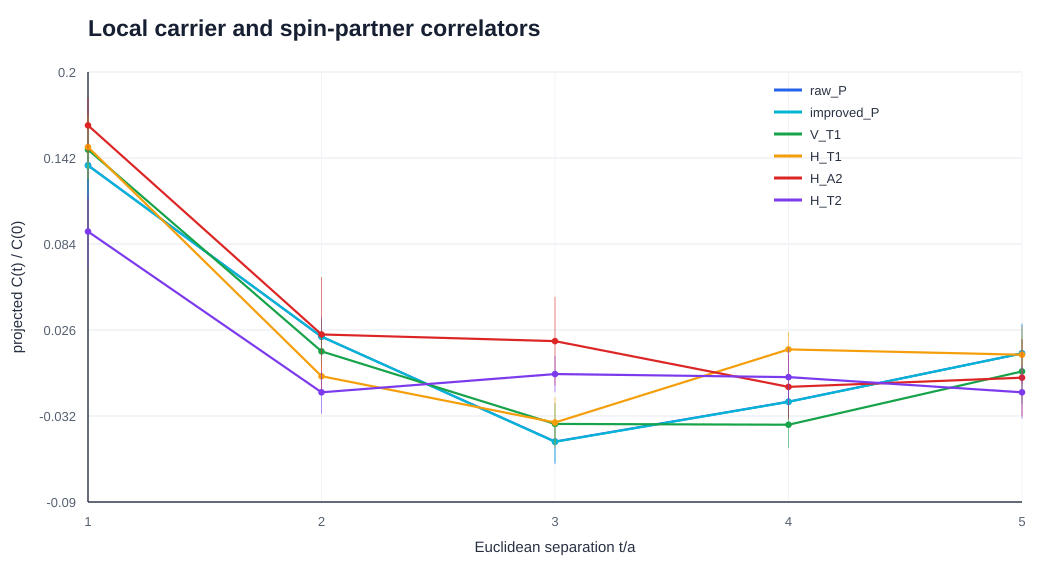

In [3]:
import matplotlib.pyplot as plt
colors = {"raw_P":"#2563eb", "improved_P":"#06b6d4", "V_T1":"#16a34a",
          "H_T1":"#f59e0b", "H_A2":"#dc2626", "H_T2":"#7c3aed"}
fig, ax = plt.subplots(figsize=(10.5, 5.7))
for name, color in colors.items():
    row = exploratory[name]
    t = np.arange(1, 6)
    ax.errorbar(t, row["curve"][1:6], row["error"][1:6], marker="o", label=name, color=color)
ax.axhline(0, color="black", lw=.8)
ax.set(xlabel="Euclidean separation t/a", ylabel="projected C(t)/C(0)",
       title="Local carrier and spin-partner correlators", xlim=(.8,5.2), ylim=(-.09,.20))
ax.legend(); ax.grid(alpha=.2); plt.show()


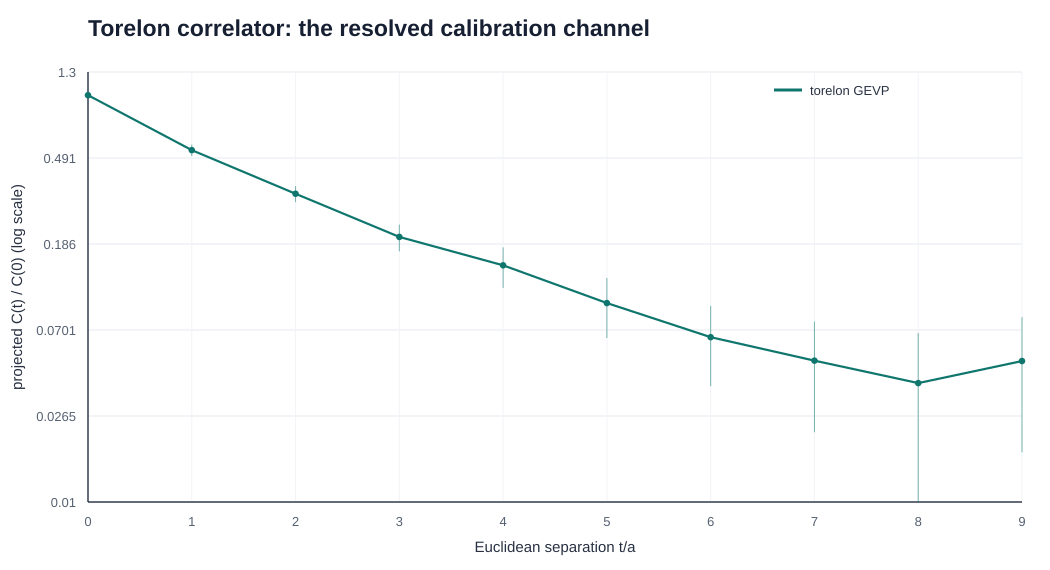

In [4]:
fig, ax = plt.subplots(figsize=(10.5, 5.7))
row = exploratory["torelon"]; t = np.arange(10)
ax.errorbar(t, row["curve"][:10], row["error"][:10], marker="o", color="#0f766e")
ax.set_yscale("log"); ax.set(xlabel="Euclidean separation t/a", ylabel="C(t)/C(0)",
    title="Torelon correlator: resolved calibration channel"); ax.grid(alpha=.2); plt.show()


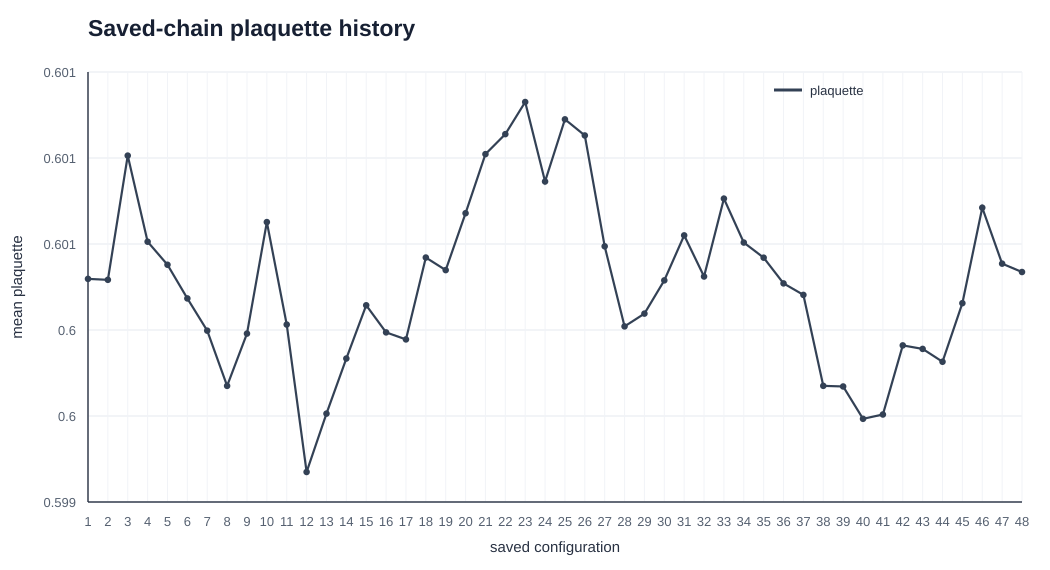

In [5]:
fig, ax = plt.subplots(figsize=(10.5, 5.7))
ax.plot(np.arange(1,49), streams["plaquette"], marker="o", ms=3, color="#334155")
ax.set(xlabel="saved configuration", ylabel="mean plaquette", title="Saved-chain plaquette history")
ax.grid(alpha=.2); plt.show()


## Decision

The measurement works and the radius choice is resolved. Keep $\rho\sqrt\sigma=0.45,0.60$. The local channels need more independent statistics before a plateau or spin-partner comparison can be claimed.